# 도킹 자동화


1. with bash
2. with python


예제 파일
*  TGFR1.zip (결과 파일 포함)
*  TGFR1_test.zip (결과 파일 제외)


# 도킹 자동화가 필요한 이유

신약개발에서 도킹은 단일 분자가 아닌 수천~수백만 개의 후보 분자를 대상으로 수행되기 때문임.[링크 텍스트](https://)

| 단계 | 규모 | 방법 |
|------|------|------|
| 초기 화합물 라이브러리 | 100만 ~ 1억 개 | 고속 가상 탐색 (HTVS) |
| 1차 필터링 | 수만 개 | 표준 도킹 |
| 2차 필터링 | 수백 개 | 정밀 도킹 + MD 시뮬레이션 |
| 실험 검증 | 수십 개 | 실제 합성 + 활성 측정 |

> 수동으로 하나씩 도킹하면 **100개만 해도 수일 소요** → 자동화 필수

# 전체 자동화 파이프라인

```
화합물 라이브러리 (SMILES)
        ↓  dock_vina.sh / dock_vina.py
  대규모 도킹 자동화
        ↓  find_pharmacophore_pdb.py
  Pharmacophore 패턴 추출 (SMARTS)
        ↓  pharmacophore.py
  공통 결합 특징 분석
        ↓
  Hit 화합물 선별 → 실험 검증
```



---



# 1. dock_vina.sh (bash 자동화)

In [ ]:
wsl
conda activate docking

In [ ]:
cat > dock_vina.sh << 'EOF'
#!/bin/bash
# 사용법: ./dock_vina.sh ligand_list.smi
# ligand_list.smi 형식: mol_id SMILES (공백 구분)

list_file=$1
dock_dir=dock
mkdir -p $dock_dir

while read line
do
    array=($line)
    mol_id=${array[0]}
    smi=${array[1]}

    # pH 7.4 protonation state 계산
    smi_p=$(~/miniconda310/envs/docking/bin/obabel -:"$smi" -p7.4 -osmi 2>/dev/null | head -1)
    echo "$mol_id: $smi_p"

    # 3D conformer 생성
    ~/miniconda310/envs/docking/bin/gen3d.py -i "$smi_p" -o $dock_dir/$mol_id.pdb

    # pdb → pdbqt 변환
    ~/miniconda310/envs/docking/bin/pdb2pdbqt.py -i $dock_dir/$mol_id.pdb \
        -o $dock_dir/$mol_id.pdbqt -l

    # 도킹 실행 (Quick Vina 2)
    ~/docking_tools/qvina02 --config config.txt \
        --ligand $dock_dir/$mol_id.pdbqt \
        --out $dock_dir/dock_$mol_id.pdbqt

    # pdbqt → pdb 변환 (bond 정보 복원)
    ~/miniconda310/envs/docking/bin/pdbqt2pdb_ref.py \
        -i $dock_dir/dock_$mol_id.pdbqt \
        -o $dock_dir/dock_$mol_id.pdb \
        -r $dock_dir/$mol_id.pdb

done < $list_file
EOF

chmod +x dock_vina.sh

In [ ]:
#필요시
# miniconda310 경로 변수 설정
PBI=~/miniconda310/envs/docking/bin

# dock_vina.sh 수정
sed -i \
    -e "s|obabel|$PBI/obabel|g" \
    -e "s|gen3d.py|$PBI/gen3d.py|g" \
    -e "s|pdb2pdbqt.py|$PBI/pdb2pdbqt.py|g" \
    -e "s|qvina02|~/docking_tools/qvina02|g" \
    -e "s|pdbqt2pdb_ref.py|$PBI/pdbqt2pdb_ref.py|g" \
    dock_vina.sh

# 수정 확인
cat dock_vina.sh

# 2. ligand_list.smi 생성

In [ ]:
cat > ligand_list.smi << 'EOF'
CHEMBL519948 Cc4cccc(c1nc(N)sc1c3ccc2nccnc2c3)n4
CHEMBL480742 Cc4nc(c1nc(N)[nH]c1c3ccc2nccnc2c3)ccc4F
CHEMBL341280 Brc4cccc(c1[nH]ncc1c2ccnc3ccccc23)n4
CHEMBL517068 CC(=O)Nc4nc(c1ccc(F)c(C)n1)c(c3ccc2ncnn2c3)[nH]4
EOF

# 3. dock_vina.py (Python 자동화)

In [ ]:
cat > dock_vina.py << 'EOF'
#!/usr/bin/env python
"""
도킹 자동화 스크립트 (Python)
사용법: python dock_vina.py vina_file config_file smi_list_file out_dir
예시:   python dock_vina.py ~/docking_tools/qvina02 config.txt ligand_list.smi dock_py
"""
import sys
import os
import subprocess
from pbi import ligandtools
from pbi.pdbtools import PDBtools
from openbabel import pybel


def add_hydrogen(smi0, pH=7.4):
    """SMILES에 pH 7.4 기준 수소 추가 후 SMILES 반환."""
    try:
        m = pybel.readstring("smi", smi0)
        m.OBMol.AddHydrogens(False, True, pH)
        smi_p = m.write("smi").strip()
    except Exception:
        smi_p = smi0
    return smi_p


def docking(vina, config_file, ligand_file, output_file):
    """Quick Vina 2 도킹 실행. 오류 시 exception 반환."""
    run_line = f'{vina} --config {config_file} --ligand {ligand_file} --out {output_file}'
    try:
        subprocess.check_output(
            run_line.split(),
            stderr=subprocess.STDOUT,
            universal_newlines=True
        )
        return None
    except Exception as e:
        return e


def main():
    if len(sys.argv) < 5:
        print('사용법: dock_vina.py vina_file config_file smi_list_file out_dir')
        sys.exit()

    vina        = sys.argv[1]
    config_file = sys.argv[2]
    list_file   = sys.argv[3]
    out_dir     = sys.argv[4]
    pH          = 7.4

    os.makedirs(out_dir, exist_ok=True)

    with open(list_file) as fp:
        lines = fp.readlines()

    for line in lines:
        lis    = line.strip().split()
        mol_id = lis[0]
        smi    = lis[1]
        print(f"Processing: {mol_id}")

        pdb_file       = f"{out_dir}/{mol_id}.pdb"
        pdbqt_file     = f"{out_dir}/{mol_id}.pdbqt"
        dock_pdbqt     = f"{out_dir}/dock_{mol_id}.pdbqt"
        dock_pdb       = f"{out_dir}/dock_{mol_id}.pdb"

        # pH 7.4 protonation
        smi_p = add_hydrogen(smi, pH=pH) if pH else smi

        # 3D conformer 생성
        ligandtools.gen_3d(smi_p, pdb_file, mol_id=mol_id,
                           file_format='pdb', timeout=20)

        # pdb → pdbqt
        PDBtools.ligand_to_pdbqt(pdb_file, pdbqt_file)

        # 도킹
        err = docking(vina, config_file, pdbqt_file, dock_pdbqt)
        if err:
            print(f"  ⚠️ 도킹 오류: {mol_id} — {err}")
            continue

        # pdbqt → pdb
        ligandtools.pdbqt_to_pdb_ref(dock_pdbqt, dock_pdb, pdb_file)
        print(f"  ✅ 완료: {dock_pdb}")


if __name__ == "__main__":
    main()
EOF

In [ ]:
#필요시
notepad "C:\Users\PC\OneDrive - emocog\문서\Simoa_Jay\8)깃허브\LAIDD_drug_discovery\structure_based_drug_discovery\3_molecular_docking\3_3_docking_automation\TGFR1\dock_vina.py"

In [ ]:
#기존
ligandtools.gen_3d(smi_p, pdb_file, mol_id=mol_id, file_format='pdb',

        timeout=20)

In [2]:
# 수정 후
ligandtools.gen_3d(smi_p, pdb_file, mol_id=mol_id, file_format='pdb')

# 4. 실행 명령어

In [ ]:
cd TGFR1

# 실행 권한 부여
chmod +x dock_vina.sh

# bash 버전 자동화 실행
./dock_vina.sh ligand_list.smi

# 결과 확인
ls dock/


# Python 버전 자동화 실행
~/miniconda310/envs/docking/bin/python dock_vina.py \
    ~/docking_tools/qvina02 \
    config.txt \
    ligand_list.smi \
    dock_py

# 결과 확인
ls dock_py/

# 5. 결과 시각화 (PyMOL)

In [ ]:
#X server로 PyMOL GUI가 있다는 가정하에, WSL에서
pymol pdb/3HMMA_receptor_HOH.pdb pdb/3HMMA_855.pdb dock/dock_*.pdb

In [ ]:
# PyMOL Windows에서
cd C:/Users/PC/OneDrive - emocog/문서/Simoa_Jay/8)깃허브/LAIDD_drug_discovery/structure_based_drug_discovery/3_molecular_docking/3_3_docking_automation/TGFR1

load pdb/3HMMA_receptor_HOH.pdb
load pdb/3HMMA_855.pdb
load dock_py/dock_CHEMBL519948.pdb
load dock_py/dock_CHEMBL480742.pdb
load dock_py/dock_CHEMBL341280.pdb
load dock_py/dock_CHEMBL517068.pdb

# 스타일 설정
hide everything
show cartoon, 3HMMA_receptor_HOH
show sticks, 3HMMA_855
show sticks, dock_CHEMBL519948
show sticks, dock_CHEMBL480742
show sticks, dock_CHEMBL341280
show sticks, dock_CHEMBL517068

# 색상 구분
color cyan, 3HMMA_receptor_HOH
color yellow, 3HMMA_855
zoom

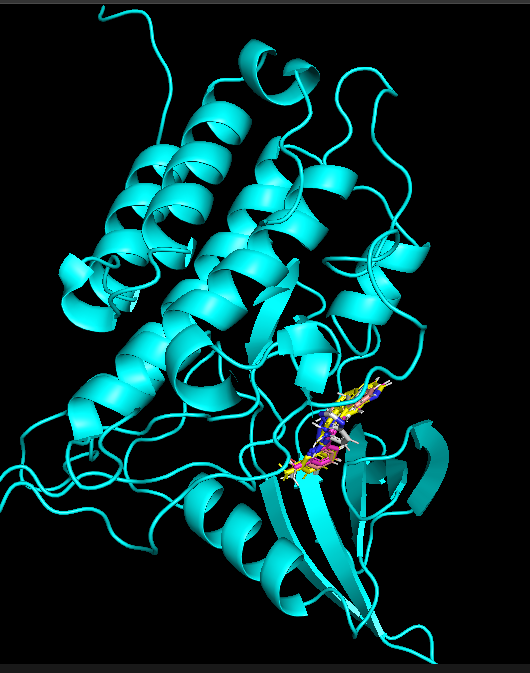



---



# 6. Docking 결과 분석 자동화

## SMARTS 및 Pharmacophore 분석

---

### SMARTS란?

SMILES의 확장 언어로, **분자 내 특정 패턴**을 검색하는 쿼리 언어입니다.

| 표현 | 예시 | 의미 |
|------|------|------|
| SMILES | `Cc1cccc(n1)` | 분자 구조 표현 |
| SMARTS | `[nH]` | 방향족 N-H 패턴 검색 |
| SMARTS | `[OH]` | 하이드록실기 검색 |
| SMARTS | `[NH2]` | 아민기 검색 |

📎 참고: https://www.daylight.com/dayhtml/doc/theory/theory.smarts.html

### 신약개발에서의 SMARTS 활용

| 용도 | 예시 |
|------|------|
| 반응성 작용기 제거 | 알데하이드, 에폭사이드 등 필터링 |
| Pharmacophore 탐색 | 수소결합 공여체/수용체 위치 탐색 |
| ADMET 필터 | 독성 관련 작용기 제거 |

---

### find_pharmacophore_pdb.py

도킹 결과 PDB 파일에서 **단백질-리간드 상호작용 부위(pharmacophore)** 를 자동으로 찾는 스크립트

| 항목 | 내용 |
|------|------|
| 입력 | 도킹된 리간드 PDB 파일들 (`dock_*.pdb`) |
| 출력 | 공통 pharmacophore 좌표 및 작용기 유형 |

**작동 원리:**
1. 각 도킹 결과에서 SMARTS로 수소결합 공여체/수용체 위치 추출
2. 여러 리간드 간 공통 위치 클러스터링
3. 결합 포켓의 핵심 상호작용 위치 동정

---

### pharmacophore.py

공통 pharmacophore를 기반으로 새로운 리간드를 **필터링** 또는 **설계** 하는 스크립트

> **Pharmacophore** = 단백질과 상호작용하는 리간드의 핵심 화학적 특징

| 특징 유형 | 해당 작용기 |
|-----------|------------|
| H-bond donor (수소결합 공여체) | N-H, O-H |
| H-bond acceptor (수소결합 수용체) | N, O |
| Hydrophobic (소수성 접촉) | 방향족, 지방족 |
| Cation (양이온성) | 양전하 질소 |

---

### 전체 자동화 파이프라인

```
화합물 라이브러리 (SMILES)
        ↓  dock_vina.sh / dock_vina.py
  대규모 도킹 자동화
        ↓  find_pharmacophore_pdb.py
  Pharmacophore 패턴 추출 (SMARTS)
        ↓  pharmacophore.py
  공통 결합 특징 분석
        ↓
  Hit 화합물 선별 → 실험 검증
```

# Step 6.1 — find_pharmacophore_pdb.py 실행하여, 단백질-리간드 상호작용 부위 확인
(reference 리간드 855의 소수성 고리 중심 좌표 추출)

1. SMARTS 패턴을 이용한 화학적 지문 검색
*   SMARTS(SMILES Arbitrary Target Specification)란: 화합물의 특정 부분 구조를 찾아내는 화학 분야의 '정규 표현식(Regular Expression)'입니다.
*   단백질과 상호작용하는 데 필수적인** '수소 결합 주개(Donor)', '수소 결합 받개(Acceptor)', '방향족 고리(Aromatic ring)' **등의 패턴을 정의합니다. 스크립트는 도킹 된 각 리간드 파일(dock_*.pdb)을 읽어 이 SMARTS 패턴과 일치하는 원자들의 목록을 추출해 냅니다.
2. 가상 원자(Pseudo-atom)와 무게 중심 계산
*   a1:a:a:a:a:a:1 패턴은 벤젠과 같은 6원환 방향족 고리를 찾는 명령어입니다. 이 과정에 가상 원자 개념이 도입되는 이유가 핵심입니다.
*   면 단위의 상호작용: 방향족 고리는 탄소 원자 하나하나가 결합하는 것이 아니라, 고리 위아래에 넓게 퍼진 파이($\pi$) 전자구름 전체가 단백질과 결합(Pi-Pi stacking 등)합니다.
*   기하학적 단순화: 따라서 스크립트는 검색된** 6개 탄소 원자의 3차원 공간 좌표(X, Y, Z)를 각각 모두 더한 뒤 6으로 나누어 평균 좌표**를 구합니다.
*   가상 원자 생성: 계산된 정중앙 평균 좌표에 물리적으로는 존재하지 않는 점, 즉 가상 원자(Pseudo-atom)를 하나 찍습니다. 이제 복잡한 6각형 링 대신** 점 하나만으로 상호작용의 중심을 완벽히 대변할 수 있게 되어 연산 효율이 극대화**됩니다.
3. 공간 맵핑 및 3차원 클러스터링(Clustering)
*   수십 개의 서로 다른 리간드들의 도킹 결과에서 추출한 '수소 결합 작용기 위치'와 '가상 원자(방향족 중심) 위치'들을 하나의 3D 가상 공간에 전부 겹쳐서 흩뿌립니다.
*   **공간 분석 알고리즘을 통해 점들이 아주 빽빽하게 뭉쳐 있는 군집(Cluster)을 찾아**냅니다.
*   전혀 다르게 생긴 여러 리간드들이 약속이라도 한 듯 특정 X, Y, Z 좌표에 똑같이 방향족 고리나 수소 결합 작용기를 배치했다면, **그 위치야말로 결합에 절대적으로 필요한 공통 파마코포어(Pharmacophore)로 확정**됩니다.
4. 도킹 스코어링 모델로의 진화
*   앞서 PyMOL 이미지 분석에서 확인했던 **"방향족 고리 3개 일치 가산점(aro)"** 기능이 바로 이 스크립트를 통해 구현된 것입니다.
*   컴퓨터는 이 스크립트가 찾아낸 공통 좌표들을 기준 삼아, **새로운 수만 개의 후보 화합물들이 해당 3D 좌표에 정확히 자신의 방향족 고리 중심(가상 원자)을 가져다 놓았는지 판별**하여 도킹 점수를 드라마틱하게 높여줍니다.

In [ ]:
cd TGFR1

In [ ]:
~/miniconda310/envs/docking/bin/python find_pharmacophore_pdb.py

## find_pharmacophore_pdb.py 실행 결과

reference 리간드 855 (`3HMMA_855.pdb`)의 **소수성 방향족 고리 중심 좌표** 4개 추출

| # | X (Å) | Y (Å) | Z (Å) | 의미 |
|---|-------|-------|-------|------|
| 1 | 12.978 | 64.211 | 4.400 | 소수성 고리 중심 1 |
| 2 | 15.542 | 66.681 | 6.614 | 소수성 고리 중심 2 |
| 3 | 17.387 | 68.980 | 2.449 | 소수성 고리 중심 3 |
| 4 | 16.222 | 67.623 | 8.757 | 소수성 고리 중심 4 |

> **추출 원리:** SMARTS 패턴 (`a1:a:a:a:a:a:1` 등)으로 방향족 고리를 탐색한 후,  
> 고리를 구성하는 원자들의 평균 좌표를 **pseudo-atom** (가상 원자) 으로 계산

*   데이터에 표시된 X, Y, Z 좌표(단위: Å, 옹스트롬)는 **리간드 855가 가진 4개의 넙적한 방향족 고리(Aromatic ring)들의 '정중앙 무게 중심'**을 나타냅니다.

*   컴퓨터는 고리를 구성하는 수많은 탄소 원자들을 일일이 계산하는 대신, 이 4개의 가상 점(Point 1~4)만을 리간드의 **소수성 핵심 뼈대**로 인식하여 연산 속도와 효율을 극대화하게 됩니다.

*   이 좌표들은 TGFR1 단백질(3HMMA)과 완벽하게 결합한다고 이미 밝혀진 기준 약물(Reference)의 정보입니다.

*   즉, 이 4개의 3D 좌표는 새로운 신약 후보 물질을 평가할 때 **"최소한 이 좌표들 근처에는 방향족 고리를 가져다 놓아야, 단백질과 잘 결합할 수 있다"**는 절대적인 기준점이 됩니다

*   Vina의 도킹 점수에 "방향족 고리(aro) 3개 위치 일치 시 가산점"을 주어 농축도(EF 1%)를 3배 이상 폭발적으로 끌어올렸던 것을 기억하실 것입니다.

*   그 가산점을 주는 기준이 바로 이 데이터입니다. 수만 개의 가짜 약물을 도킹 시킨 후, 각 약물의 방향족 고리 좌표가 위 표에 나온 4개의 (X, Y, Z) 중심점 중 3개 이상과 거리가 가깝게 겹친다면(예: 반경 1.5Å 이내) 추가 점수를 부여하여 진짜 약물로 분류해 내는 알고리즘이 완성됩

# Step 6.2 — pharmacophore.py 실행하여, 상호작용 지역의 pharmacophore 만족 여부 판정
(도킹된 4개 리간드가 pharmacophore 조건을 충족하는지 평가)

In [ ]:
~/miniconda310/envs/docking/bin/python pharmacophore.py

## pharmacophore.py 실행 결과

각 도킹 결과 리간드에 대해 **Score** 와 **Pharmacophore 충족 여부** 평가

| 리간드 | Best Score (kcal/mol) | Pharmacophore 충족 (Mode 1) | 최종 평가 |
|--------|----------------------|----------------------------|-----------|
| CHEMBL519948 | -9.0 | ✅ 1 | Hit |
| CHEMBL480742 | -9.6 | ✅ 1 | Hit |
| CHEMBL341280 | -10.3 | ✅ 1 | Hit |
| CHEMBL517068 | **-11.2** | ✅ 1 | **Best Hit** |

---

### 출력값 해석

| 출력 | 의미 |
|------|------|
| Score 배열 | 10개 도킹 자세의 결합 친화도 (kcal/mol), 낮을수록 강한 결합 |
| Prediction 배열 | 각 자세의 pharmacophore 충족 여부 (1=충족, 0=미충족) |

---

### 주요 관찰

- **CHEMBL517068** — Score -11.2 kcal/mol로 가장 강한 결합 + Mode 1~4 pharmacophore 충족
- **CHEMBL341280** — Score -10.3 kcal/mol, Mode 1~2만 pharmacophore 충족
- **공통점:** 4개 리간드 모두 Mode 1에서 pharmacophore 충족 (prediction=1)
- **pharmacophore cutoff = 2.5 Å** 기준 — 소수성 고리 중심이 reference 좌표 2.5Å 이내에 위치해야 충족

---

### Pharmacophore 필터링 효과

```
10개 도킹 자세 중 pharmacophore 충족 자세만 선별
→ Score가 높아도 pharmacophore 미충족 자세는 제외
→ 결합 포켓 핵심 상호작용을 유지하는 자세만 최종 후보
```

## Pharmacophore란?

**Pharmacophore** = 단백질과의 결합에 **필수적인** 리간드의 3D 화학적 특징 집합

> 분자의 특정 구조가 아니라, **어떤 위치에 어떤 화학적 성질이 있어야 하는가**를 정의

### 핵심 개념

| 항목 | 설명 |
|------|------|
| 정의 | 생물학적 활성에 필요한 분자의 3D 화학적 특징 |
| 구성 요소 | 수소결합 공여체/수용체, 소수성 부위, 전하 부위 |
| 활용 | 새로운 화합물이 동일한 결합 특성을 가지는지 필터링 |

### 이 실습에서의 Pharmacophore

reference 리간드 855의 **소수성 방향족 고리 3개**가 pharmacophore 기준:

| Pharmacophore 포인트 | 좌표 | 의미 |
|---------------------|------|------|
| 포인트 1 | (12.978, 64.211, 4.400) | 방향족 고리 중심 A |
| 포인트 2 | (17.387, 68.980, 2.449) | 방향족 고리 중심 B |
| 포인트 3 | (15.542, 66.681, 6.614) + (16.222, 67.623, 8.757) | 방향족 고리 중심 C |

> **충족 조건:** 새 리간드의 방향족 고리 중심이 각 포인트 **2.5Å 이내**에 위치해야 함  
> **판정:** 3개 포인트 모두 충족 시 → prediction = **1** (Hit)

---

## Mode 1~4란?

도킹 프로그램은 리간드의 결합 자세를 **여러 개** 탐색합니다.  
각 자세를 **Mode** (또는 Rank)라고 합니다.

| Mode | 의미 |
|------|------|
| Mode 1 | 가장 낮은 score (최적 결합 자세) |
| Mode 2 | 두 번째로 낮은 score |
| Mode N | N번째 결합 자세 |

### CHEMBL517068 예시

| Mode | Score (kcal/mol) | Pharmacophore 충족 |
|------|-----------------|-------------------|
| 1 | -11.2 | ✅ 1 |
| 2 | -11.0 | ✅ 1 |
| 3 | -10.4 | ✅ 1 |
| 4 | -10.0 | ✅ 1 |
| 5~10 | -9.3 ~ -8.9 | ❌ 0 |

> **해석:** Mode 1~4는 score가 높고 pharmacophore도 충족  
> → 결합 포켓 내 올바른 자세로 결합하는 것으로 판단  
> Mode 5 이후는 score가 낮거나 pharmacophore 미충족 → 비특이적 자세

### 왜 여러 Mode를 보는가?

```
Mode 1만 보면:  score는 좋지만 pharmacophore 미충족 자세가 최적일 수 있음
                → 실제로는 결합 포켓이 아닌 다른 곳에 결합한 자세일 가능성
                
Mode 1~N 전체:  score + pharmacophore 동시 충족 자세 수 확인
                → 여러 자세에서 일관되게 충족 = 더 신뢰할 수 있는 결합 예측
```